# 📝 E-commerce customer churn analysis

## 🌟 Highlights 
From this project "E-commerce customer churn analysis", the highlights are addressed as:
- Discover the relationship between each features and churn. Among all, tenure has the highest negative correlation (-0.34) with churn and complain has the highest correlation (0.25) with churn
- Data analysis of potential business questions
- Chosen model are RandomForest, XGBoost, LightGBM, and Catboost. Fine tune the model to prevent overfitting. The adviced model is LightGBM with the PR score of 0.827
- Action recommendation
  - Compared long term customer, new customer should be the point of focus for churn possibility.
  - Create a service team to tackle customer who raise complain or hot line to receive complain feedback.
  - Consider to set up warehouse center or intermediate service store to increase convenience toward customer living relatively far.
  - Considering higher percentage of male customer and churn possibility, should increase more products that grab their interest such as attached accessory of phone or laptop or accessory.
  - Increase products or combo deal that are more attractive to single or marrried group. Such as phone, laptop, or accessory.
  - Main selling point are phone, laptop, and accessory. Consider to offer related products when people purchase them.
## ℹ️ Project Introduction 
The general meaning of churn is that customers stop using the service provided by the companies.  
Churn analysis in e-commerce website is a commonly used technique to analyze customer behavior and predict whether customers will leave the service (churn).    
From the analysis outcome, e-commerce companies can perform proactive actions, such as reach out potential churn customers to prevent profit loss or analyze common traits for product/service improvement

## 🎯 Mission & Goal
- Perform exploratory analysis to gain insight into customer behavior and characteristics of customers The discovered pattern can be used for the decision making in the future.  
- Build a churn prediction model to predict customer churn

## 🏭 Build Flow
- Import libraries
- Data preprocessing
- EDA
- Model training
- Model evaluation
- Action recommendation

## Import libraries

In [2]:
import time

# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

# Evaluation Metrics
from sklearn.metrics import (
    confusion_matrix, 
    classification_report, 
    roc_auc_score, 
    average_precision_score, # This is the PR score
    precision_recall_curve,
    accuracy_score
)

from sklearn.inspection import permutation_importance
import warnings
warnings.simplefilter(action='ignore')

## Data Preprocessing
- Adjust data type (object to category for model training) 
- Drop useless column (CustomerID)
- Merge the similar values in columns

<div style="background-color: #f5f5dc; 
            padding: 20px 30px; 
            border-radius: 20px; 
            box-shadow: 8px 8px 15px rgba(0,0,0,0.4); 
            border: 1px solid #dcdcdc;
            color: #2c2c2c;
            font-family: sans-serif;">

<h4 style="margin-top: 0; margin-bottom: 15px; font-weight: 400; font-size: 1.1em;"><b>Columns introduction</b></h4>

<ul style="margin-bottom: 0; line-height: 1.8;">
  <li><b>CustomerID:</b> Unique customer ID.</li>
  <li><b>Churn:</b> Churn flag.</li>
  <li><b>Tenure:</b> Tenure of customer in organization.</li>
  <li><b>PreferredLoginDevice:</b> Preferred login device of customer.</li>
  <li><b>CityTier:</b> City tier.</li>
  <li><b>WarehouseToHome:</b> Distance between warehouse and customer home.</li>
  <li><b>PreferredPaymentMode:</b> Preferred payment method of customer.</li>
  <li><b>Gender:</b> Gender of customer.</li>
  <li><b>HourSpendOnApp:</b> Number of hours spent on mobile application or website.</li>
  <li><b>NumberOfDeviceRegistered:</b> Total number of devices registered by customer.</li>
  <li><b>PreferedOrderCat:</b> Preferred order category of customer in last month.</li>
  <li><b>SatisfactionScore:</b> Customer satisfaction score on service.</li>
  <li><b>MaritalStatus:</b> Marital status of customer.</li>
  <li><b>NumberOfAddress:</b> Total number of addresses added by customer.</li>
  <li><b>Complain:</b> Whether any complaint was raised in last month.</li>
  <li><b>OrderAmountHikeFromlastYear:</b> Percentage increase in order amount from last year.</li>
  <li><b>CouponUsed:</b> Total number of coupons used in last month.</li>
  <li><b>OrderCount:</b> Total number of orders placed in last month.</li>
  <li><b>DaySinceLastOrder:</b> Days since last order by customer.</li>
  <li><b>CashbackAmount:</b> Average cashback amount in last month.</li>
</ul>

</div>

In [3]:
# df_col_discription = pd.read_excel('E Commerce Dataset.xlsx', sheet_name='Data Dict')
# df_col_discription.columns = df_col_discription.iloc[0]
# df_col_discription = df_col_discription.iloc[1:]
# df_col_discription['Total'] = df_col_discription['Variable'] + ': ' + df_col_discription['Discerption']
# for i in list(df_col_discription['Total']):
#     print(i)

In [4]:
df = pd.read_excel('E Commerce Dataset.xlsx', sheet_name='E Comm')
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [5]:
# CustomerID is useless
df = df.drop(columns=['CustomerID'], axis=1)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Churn                        5630 non-null   int64  
 1   Tenure                       5366 non-null   float64
 2   PreferredLoginDevice         5630 non-null   object 
 3   CityTier                     5630 non-null   int64  
 4   WarehouseToHome              5379 non-null   float64
 5   PreferredPaymentMode         5630 non-null   object 
 6   Gender                       5630 non-null   object 
 7   HourSpendOnApp               5375 non-null   float64
 8   NumberOfDeviceRegistered     5630 non-null   int64  
 9   PreferedOrderCat             5630 non-null   object 
 10  SatisfactionScore            5630 non-null   int64  
 11  MaritalStatus                5630 non-null   object 
 12  NumberOfAddress              5630 non-null   int64  
 13  Complain          

In [7]:
for col in df.columns:
    if col == 'CustomerID':
        continue
    else:
        print(f'This is column: {col}')
        print('=========================================')
        print('Value counts')
        print(df[col].value_counts())
        print('-----------------------------------------')
        print('Value counts: Null')
        print(df[col].isna().value_counts())
        print('\n')

This is column: Churn
Value counts
0    4682
1     948
Name: Churn, dtype: int64
-----------------------------------------
Value counts: Null
False    5630
Name: Churn, dtype: int64


This is column: Tenure
Value counts
1.0     690
0.0     508
8.0     263
9.0     247
7.0     221
10.0    213
5.0     204
4.0     203
3.0     195
11.0    194
6.0     183
12.0    182
13.0    181
14.0    176
2.0     167
15.0    159
16.0    149
19.0    140
18.0    123
20.0    109
17.0    106
23.0     89
21.0     84
22.0     76
24.0     75
28.0     70
30.0     66
27.0     66
26.0     60
25.0     59
29.0     55
31.0     49
50.0      1
60.0      1
51.0      1
61.0      1
Name: Tenure, dtype: int64
-----------------------------------------
Value counts: Null
False    5366
True      264
Name: Tenure, dtype: int64


This is column: PreferredLoginDevice
Value counts
Mobile Phone    2765
Computer        1634
Phone           1231
Name: PreferredLoginDevice, dtype: int64
-----------------------------------------
Value c

In [8]:
# PreferedOrderCat: Mobile is the same as Mobile Phone --> Merge
# PreferredLoginDevice: Phone is the same as Mobile Phone --> Merge
df['PreferedOrderCat'] = df['PreferedOrderCat'].apply(lambda x: 'Mobile Phone' if x == 'Mobile' else x)
df['PreferredLoginDevice'] = df['PreferredLoginDevice'].apply(lambda x: 'Mobile Phone' if x == 'Phone' else x)

# PreferredPaymentMode: COD is the same as Cash on Delivery and CC is the same as Credit Card
df['PreferredPaymentMode'] = df['PreferredPaymentMode'].apply(lambda x: 'Cash on Delivery' if x == 'COD' else 'Credit Card' if x == 'CC' else x)

In [9]:
print(df['PreferedOrderCat'].value_counts())
print(df['PreferredLoginDevice'].value_counts())
print(df['PreferredPaymentMode'].value_counts())

Mobile Phone          2080
Laptop & Accessory    2050
Fashion                826
Grocery                410
Others                 264
Name: PreferedOrderCat, dtype: int64
Mobile Phone    3996
Computer        1634
Name: PreferredLoginDevice, dtype: int64
Debit Card          2314
Credit Card         1774
E wallet             614
Cash on Delivery     514
UPI                  414
Name: PreferredPaymentMode, dtype: int64


In [10]:
# Change object column into category column for later use
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].astype('category')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   Churn                        5630 non-null   int64   
 1   Tenure                       5366 non-null   float64 
 2   PreferredLoginDevice         5630 non-null   category
 3   CityTier                     5630 non-null   int64   
 4   WarehouseToHome              5379 non-null   float64 
 5   PreferredPaymentMode         5630 non-null   category
 6   Gender                       5630 non-null   category
 7   HourSpendOnApp               5375 non-null   float64 
 8   NumberOfDeviceRegistered     5630 non-null   int64   
 9   PreferedOrderCat             5630 non-null   category
 10  SatisfactionScore            5630 non-null   int64   
 11  MaritalStatus                5630 non-null   category
 12  NumberOfAddress              5630 non-null   int64   
 13  Com

In [11]:
original_rows = df.shape[0]
remaining_rows = df.dropna(axis=0).shape[0]
print(f'There are {original_rows} rows in total')
print(f'There are {remaining_rows} rows after dropping rows with NaN missing value')

There are 5630 rows in total
There are 3774 rows after dropping rows with NaN missing value


## EDA - Business Questions
1. What is the distribution insight from churn columns and features?
2. Which gender has more orders
3. Which CityTier has higher Tenure and OrderCount?
4. Which CityTier has the most HourSpendOnApp?
5. What is the distance between warehouse to customer house in different city tiers?
6. Which MaritalStatus makes more OrderCount?
7. Does getting more cashback lead to more orders?
8. Do people spend more money when they use coupons?
9. Do customers with high SatisfactionScore spend more hours on the app?
10. Do customers with high SatisfactionScore have more OrderCount?
11. Do customers with more HourSpendOnApp have more OrderCount?
12. Do people with more registered devices buy more often?
13. What is the most common payment method for high-value customers?
14. What kind of product do male or female buy the most?
15. What kind of product do people from different marital status buy the most?

**Initial findings**
- Imbalanced dataset in terms of churn
- Almost 20% of people has satisfaction score of 1
- 28% people raised complain last month

In [12]:
df_eda = df.copy()

continuous_num_columns = ['Tenure', 'WarehouseToHome', 'OrderAmountHikeFromlastYear', 'CashbackAmount']
discrete_num_columns = ['CityTier', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress', 'Complain', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder']
cat_columns = ['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender', 'PreferedOrderCat', 'MaritalStatus']

### What is the distribution insight from churn columns and features?

#### Continuous numeric columns

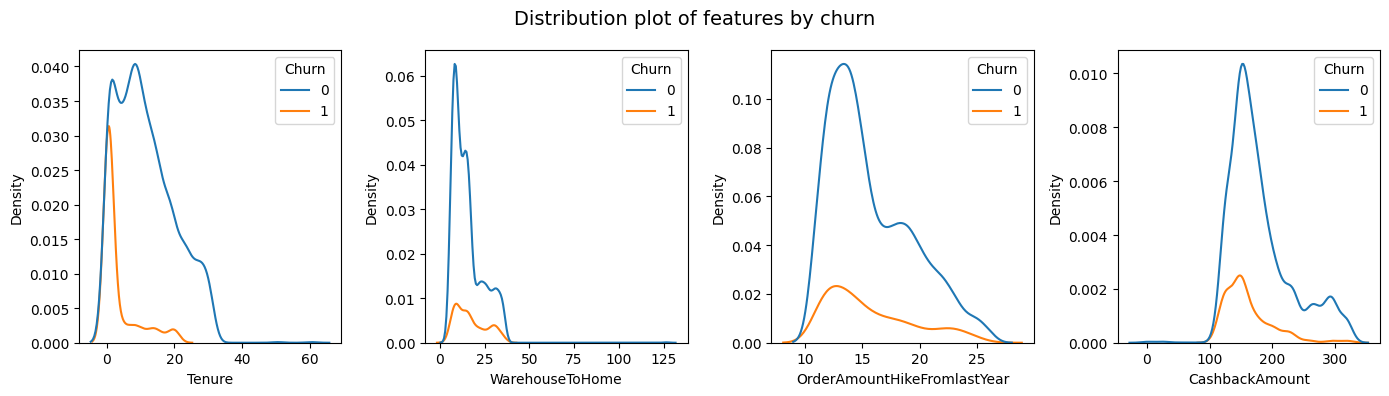

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
fig.suptitle('Distribution plot of features by churn', fontsize=14)
axes = axes.flatten()
for i, col in enumerate(continuous_num_columns):
    sns.kdeplot(x=col, 
                data=df_eda,
                hue='Churn',
                ax=axes[i],
                # common_norm=False  # Make area udner each curve to 1
               )
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')
plt.tight_layout()
plt.show()

#### Discrete numeric columns

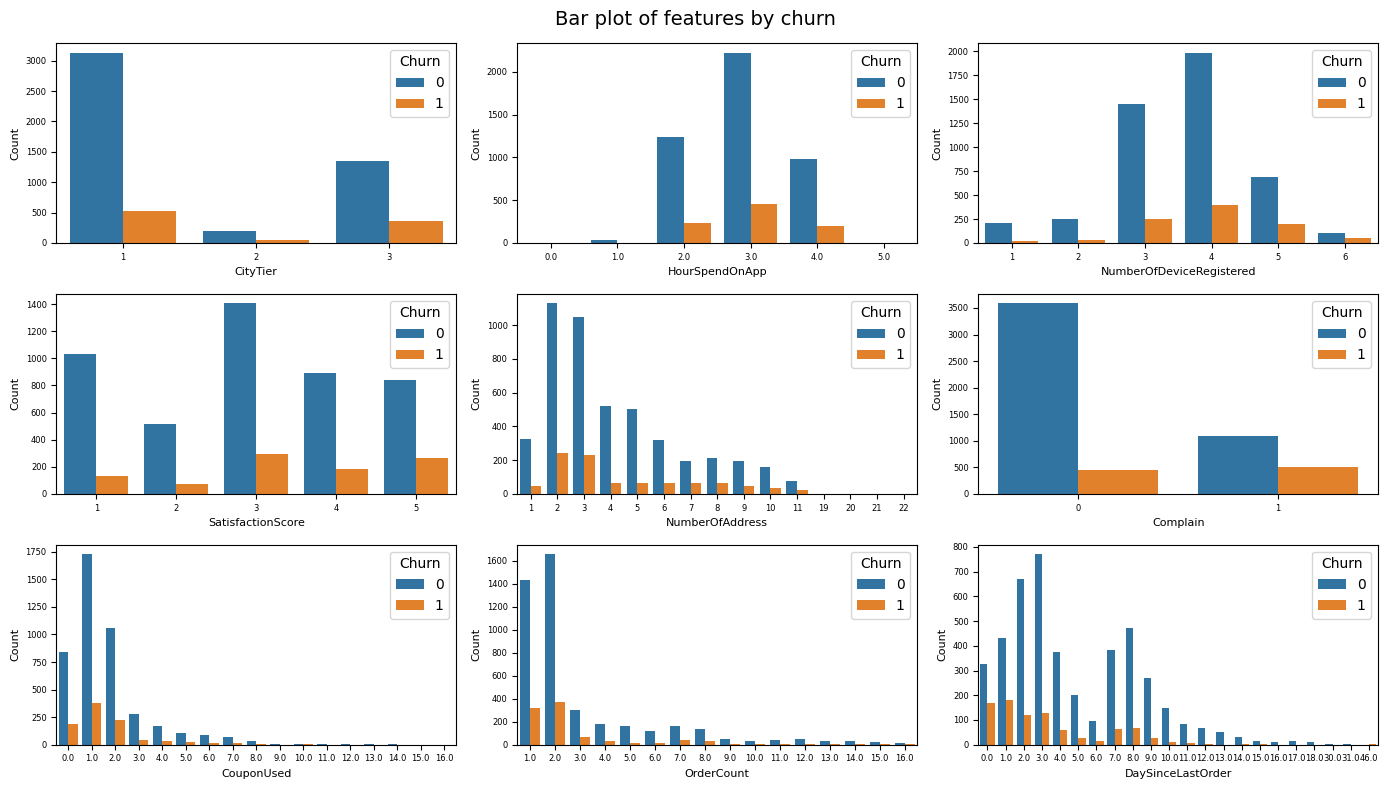

In [14]:
fig, axes = plt.subplots(3, 3, figsize=(14, 8))
fig.suptitle('Bar plot of features by churn', fontsize=14)
axes = axes.flatten()  # Convert from 2D to 1D
for i, col in enumerate(discrete_num_columns):
    df_col_churn = df_eda.groupby([col, 'Churn'])['Churn'].count().reset_index(name='Count')
    sns.barplot(x=col,
                y='Count',
                data=df_col_churn,
                hue='Churn',
                ax=axes[i],
               )
    axes[i].set_xlabel(col, fontsize=8)
    axes[i].set_ylabel('Count', fontsize=8)
    axes[i].tick_params(labelsize=6)
plt.tight_layout()
plt.show()

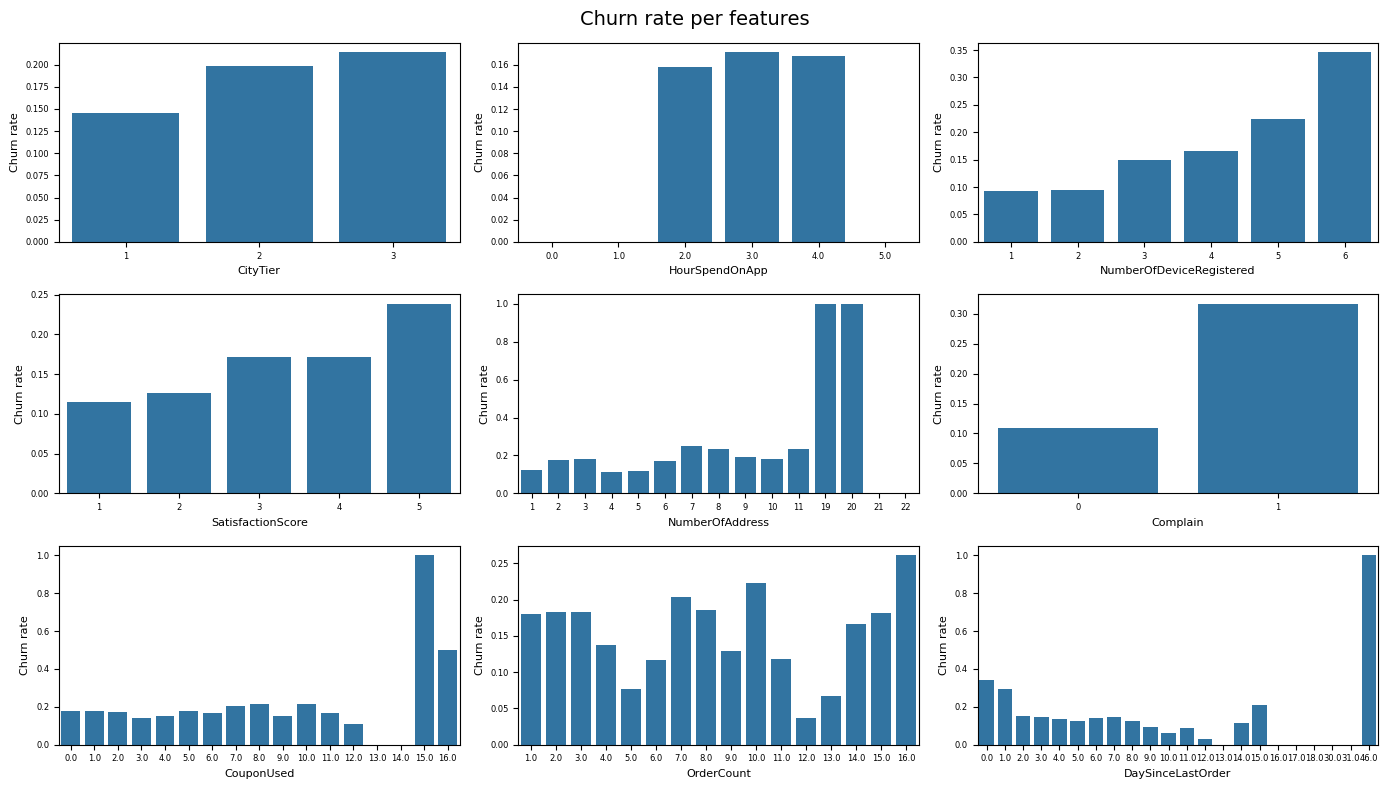

In [15]:
# Discrete numeric columns
fig, axes = plt.subplots(3, 3, figsize=(14, 8))
fig.suptitle('Churn rate per features', fontsize=14)
axes = axes.flatten()  # Convert from 2D to 1D
for i, col in enumerate(discrete_num_columns):
    df_col_churn_rate = df_eda.groupby([col])['Churn'].mean().reset_index(name='Churn rate')
    sns.barplot(x=col,
                y='Churn rate',
                data=df_col_churn_rate,
                ax=axes[i])
    axes[i].set_xlabel(col, fontsize=8)
    axes[i].set_ylabel('Churn rate', fontsize=8)
    axes[i].tick_params(labelsize=6)
plt.tight_layout()
plt.show()

#### Categorical columns

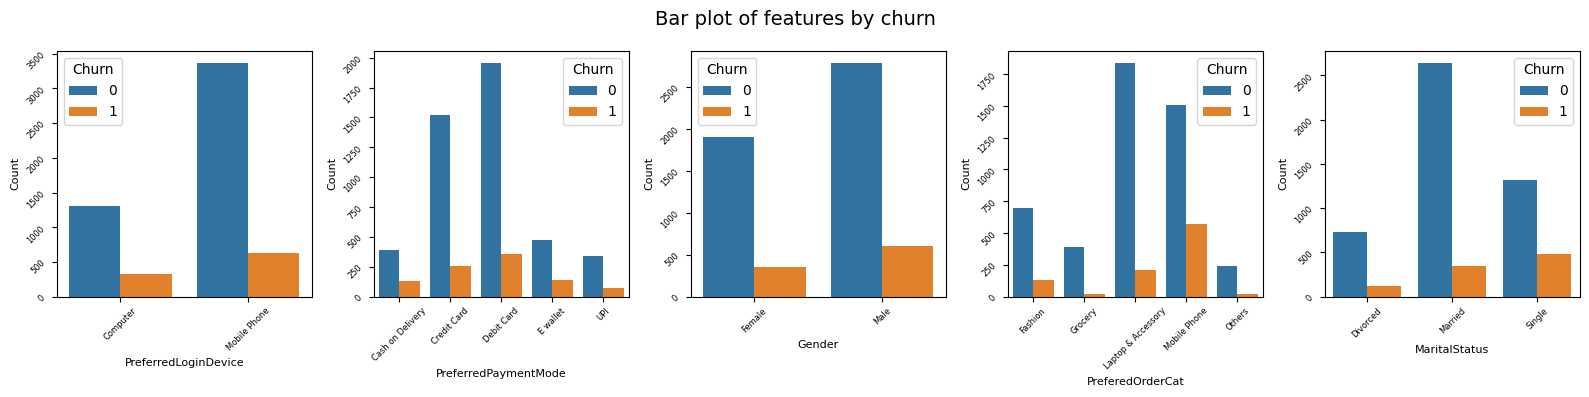

In [16]:
fig, axes = plt.subplots(1, 5, figsize=(16, 4))
fig.suptitle('Bar plot of features by churn', fontsize=14)
axes = axes.flatten()
for i, col in enumerate(cat_columns):
    df_col_churn = df_eda.groupby([col, 'Churn'])['Churn'].count().reset_index(name='Count')
    sns.barplot(x=col,
                y='Count',
                data=df_col_churn,
                hue='Churn',
                ax=axes[i]
               )
    axes[i].set_xlabel(col, fontsize=8)
    axes[i].set_ylabel('Count', fontsize=8)
    axes[i].tick_params(labelrotation=45, labelsize=6)
plt.tight_layout()
plt.show()

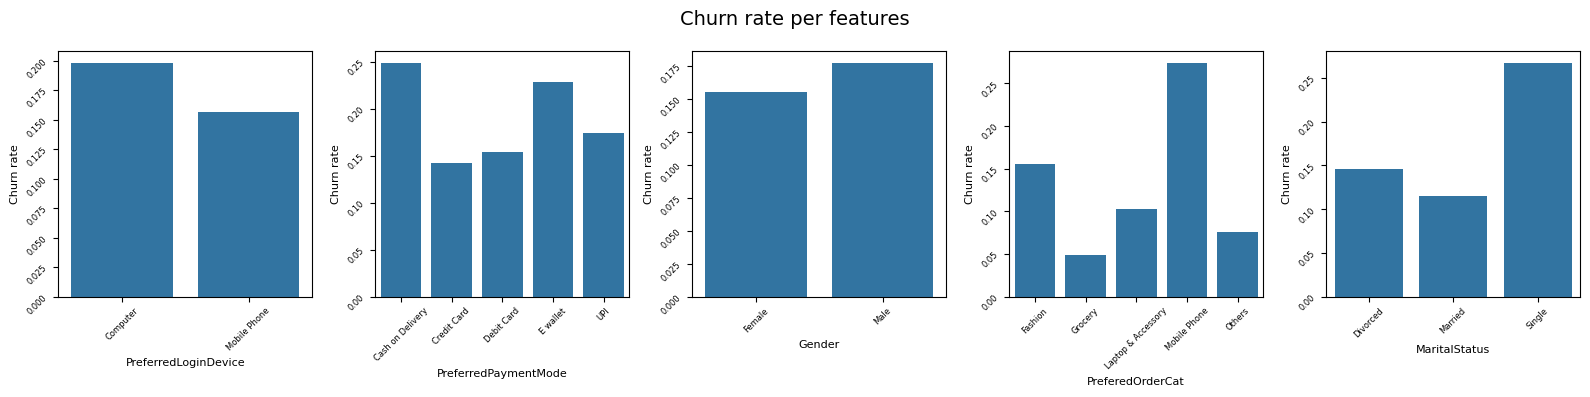

In [17]:
fig, axes = plt.subplots(1, 5, figsize=(16, 4))
fig.suptitle('Churn rate per features', fontsize=14)
axes = axes.flatten()
for i, col in enumerate(cat_columns):
    df_col_churn = df_eda.groupby([col])['Churn'].mean().reset_index(name='Churn rate')
    sns.barplot(x=col,
                y='Churn rate',
                data=df_col_churn,
                ax=axes[i]
               )
    axes[i].set_xlabel(col, fontsize=8)
    axes[i].set_ylabel('Churn rate', fontsize=8)
    axes[i].tick_params(labelrotation=45, labelsize=6)
plt.tight_layout()
plt.show()

<div style="background-color: #f5f5dc; 
            padding: 20px 30px; 
            border-radius: 20px; 
            box-shadow: 8px 8px 15px rgba(0,0,0,0.4); 
            border: 1px solid #dcdcdc;
            color: #2c2c2c;
            font-family: sans-serif;">

<h4 style="margin-top: 0; margin-bottom: 15px; font-weight: 400; font-size: 1.1em;"><b>Distribution insight from churn columns and features</b></h4>

<ul style="margin-bottom: 0; line-height: 1.8;">
  <li><b>Tenure:</b> People with lower tenure are likely to churn compared to people with higher tenure.</li>
  <li><b>PreferredLoginDevice:</b> People who use computer as login device have higher chrun rate. More people use mobile phone as login device due to convenience. </li>
  <li><b>CityTier:</b> People from city tier 3 are more likely to churn</li>
  <li><b>WarehouseToHome:</b> Churn rate is higher when warehouse to home is higher. It indicates the convenience factor.</li>
  <li><b>PreferredPaymentMode:</b> Majority of people use debit or credit card for payment. Among all, churn rate of cash on delivery is highest. </li>
  <li><b>Gender:</b> More users are male and likely to churn. </li>
  <li><b>HourSpendOnApp:</b> Pattern are similar.</li>
  <li><b>NumberOfDeviceRegistered:</b> Churn rate has uptrend as more devices are registered</li>
  <li><b>PreferedOrderCat:</b> People whose prefered order category is mobile phone are likely to churn. Reason could be a one-time purchase. </li>
  <li><b>SatisfactionScore:</b> People with higher satisfaction score are likely to churn.</li>
  <li><b>MaritalStatus:</b> Sigle group is likely to churn. </li>
  <li><b>NumberOfAddress:</b> Excluding NumberOfAddress of 19 and 20 due to low volume, churn rate is quite similar across different number of address. </li>
  <li><b>Complain:</b> People who complaint are likely to churn. Strong indicator.</li>
  <li><b>OrderAmountHikeFromlastYear:</b> Peak area of people who churn have around 10~15% order increase last year. Big spenders (higher order percentage increase) contribute less churn.</li>
  <li><b>CouponUsed:</b> Excluding CouponUsed of 15 and 16 due to low volumne, churn rate is quite similar across different coupon count used.</li>
  <li><b>OrderCount:</b> No strong correlation.</li>
  <li><b>DaySinceLastOrder:</b> No strong correlation. High churn rate from day 0 and 1 might be from single buyer</li>
  <li><b>CashbackAmount:</b> Churn rate is higher when cashback amount is between 100 and 150.</li>
</ul>

</div>

### Which gender has more orders?
Female is slightly higher than male.

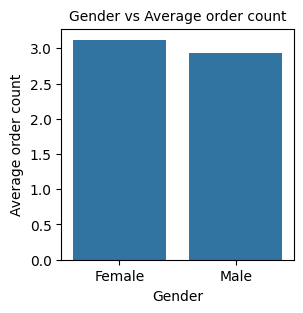

In [18]:
plt.figure(figsize=(3, 3))
df_gender_ordercount = df_eda.groupby(['Gender'])['OrderCount'].mean().reset_index(name='Average order count')
sns.barplot(x='Gender',
            y='Average order count',
            data=df_gender_ordercount)
plt.xlabel('Gender', fontsize=10)
plt.ylabel('Average order count', fontsize=10)
plt.title('Gender vs Average order count', fontsize=10)
plt.show()

### Which CityTier has higher Tenure and OrderCount?
Tier 2 city has sligtly higher average tenure. Not big difference between tiers.    
Tier 3 city has slightly higher average order count. Not big difference between tiers.  
Higher tenure does not guarantee higher order count.  

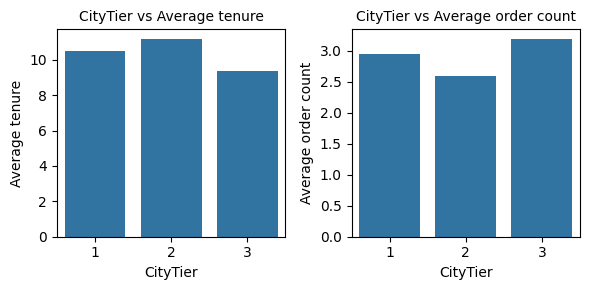

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
df_citytier_tenure = df_eda.groupby(['CityTier'])['Tenure'].mean().reset_index(name='Average tenure')
df_citytier_ordercount = df_eda.groupby(['CityTier'])['OrderCount'].mean().reset_index(name='Average order count')

sns.barplot(x='CityTier',
            y='Average tenure',
            data=df_citytier_tenure, 
            ax=axes[0])
axes[0].set_xlabel('CityTier', fontsize=10)
axes[0].set_ylabel('Average tenure', fontsize=10)
axes[0].set_title('CityTier vs Average tenure', fontsize=10)

sns.barplot(x='CityTier',
            y='Average order count',
            data=df_citytier_ordercount, 
            ax=axes[1])
axes[1].set_xlabel('CityTier', fontsize=10)
axes[1].set_ylabel('Average order count', fontsize=10)
axes[1].set_title('CityTier vs Average order count', fontsize=10)

plt.tight_layout()
plt.show()

### Which CityTier has the most HourSpendOnApp?
Tier 1 city has the highest HourSpendOnApp in total.

In [20]:
df_citytier_hourspendonapp = df_eda.groupby(['CityTier'])['HourSpendOnApp'].sum().reset_index(name='Average HourSpendOnApp')
df_citytier_hourspendonapp

,CityTier,Average HourSpendOnApp
0,1,10221.0
1,2,642.0
2,3,4894.0


### What is the distance between warehouse to customer house in different city tiers?
The distance distribution profile is similar for each city tier. Majority of distance between warehouse and home is around 25

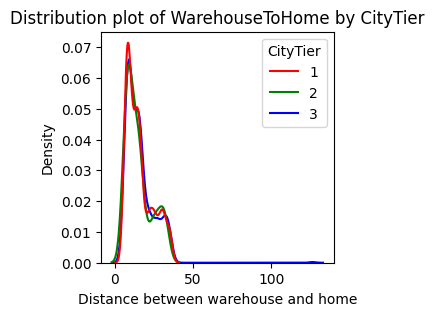

In [38]:
plt.figure(figsize=(3, 3))
sns.kdeplot(x='WarehouseToHome',
            data=df_eda, 
            hue='CityTier',
            palette=['red', 'green', 'blue'],
            common_norm=False  # Make area under each curve 1
           )
plt.xlabel('Distance between warehouse and home')
plt.ylabel('Density')
plt.title('Distribution plot of WarehouseToHome by CityTier')
plt.show()

### Which MaritalStatus makes more OrderCount?
Distribution: Married > Single > Divorced.  
Married people have higher bar distribution of OrderCount, indicating higher order demand.

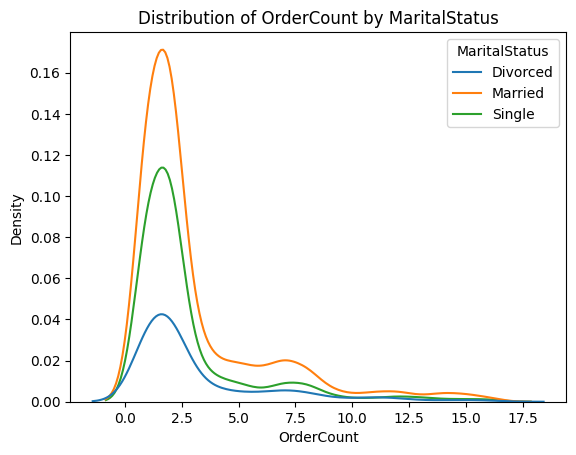

In [22]:
sns.kdeplot(x='OrderCount',
            data=df_eda, 
            hue='MaritalStatus',
           )
plt.title('Distribution of OrderCount by MaritalStatus')
plt.show()

### Does getting more cashback lead to more orders?
More cashbackAmount does not lead to more orders.

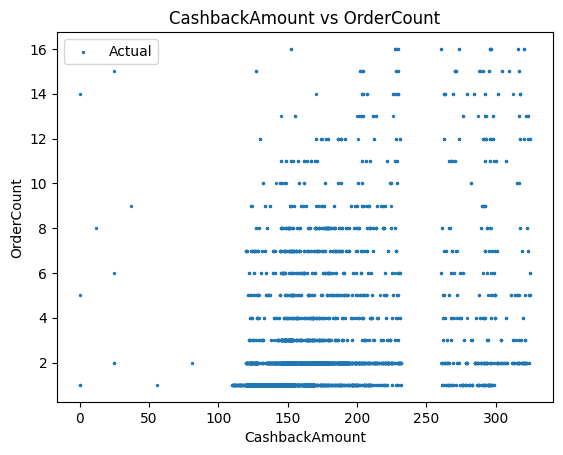

In [23]:
plt.scatter(df_eda['CashbackAmount'], df_eda['OrderCount'], s=2, label='Actual')
plt.xlabel('CashbackAmount')
plt.ylabel('OrderCount')
plt.legend()
plt.title('CashbackAmount vs OrderCount')
plt.show()

### Do people spend more money when they use coupons?
Use CashbackAmount as indicator of spending.  
Do not see more spending when coupons are used.  

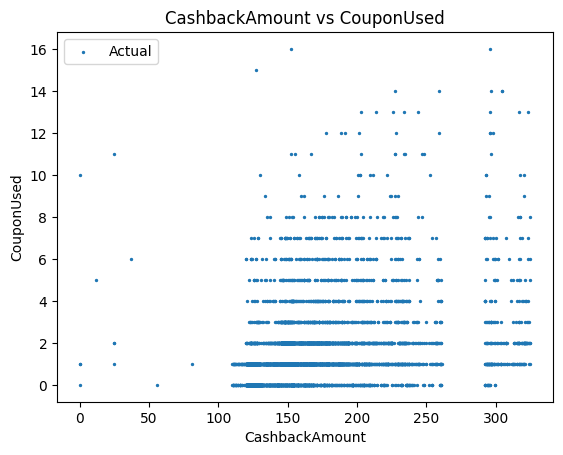

In [24]:
plt.scatter(df_eda['CashbackAmount'], df_eda['CouponUsed'], s=2, label='Actual')
plt.xlabel('CashbackAmount')
plt.ylabel('CouponUsed')
plt.legend()
plt.title('CashbackAmount vs CouponUsed')
plt.show()

### Do customers with high SatisfactionScore spend more hours on the app?
People spend similar average amount of time on app across all satisfaction scores 

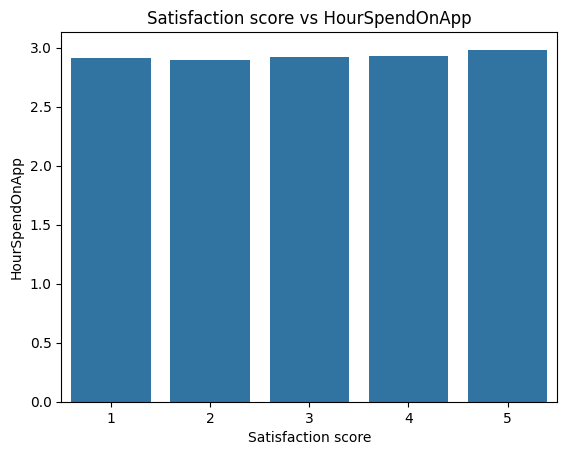

In [25]:
df_eda_satis_hours = df_eda.groupby(['SatisfactionScore'])['HourSpendOnApp'].mean().reset_index(name='Average HourSpendOnApp')
sns.barplot(x='SatisfactionScore',
            y='Average HourSpendOnApp',
            # color='Churn',
            data=df_eda_satis_hours
           )
plt.xlabel('Satisfaction score')
plt.ylabel('HourSpendOnApp')
plt.title('Satisfaction score vs HourSpendOnApp')
plt.show()

### Do customers with high SatisfactionScore have more OrderCount?
People have the similar order count across different satisfaction score.

In [26]:
df_eda_satis_order = df_eda.groupby(['SatisfactionScore'])['OrderCount'].mean().reset_index(name='Average order count')
df_eda_satis_order

,SatisfactionScore,Average order count
0,1,2.956250
1,2,2.991039
2,3,2.956119
3,4,3.004902
4,5,3.154356


### Do customers with more HourSpendOnApp have more OrderCount?
Majority of data points are located at 2, 3, and 4 hours.  
Comparing 2, 3, and 4 hours, the main distribution ranking: 4 hours > 3 hours > 2 hours.  

In [27]:
df_eda_hourspend_order = df_eda.groupby(['HourSpendOnApp'])['OrderCount'].count().reset_index(name='Count')
df_eda_hourspend_order

,HourSpendOnApp,Count
0,0.0,2
1,1.0,33
2,2.0,1398
3,3.0,2575
4,4.0,1106
5,5.0,3


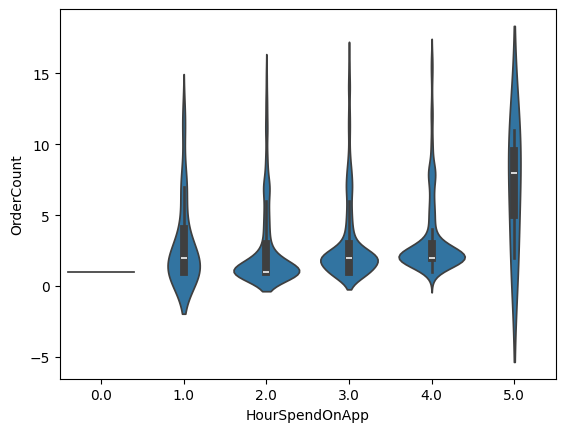

In [28]:
sns.violinplot(x='HourSpendOnApp', y='OrderCount', data=df_eda)
plt.show()

### Do people with more registered devices buy more often?
Boxplot: middle 50% of people overlays quite well around 2~3 orders when devices are >=2.    
Violinplot: Majority of people with more than 1 device have slightly higher order count (from 1 to 2).  
Increasing number of devices does not mean more order. we only see slight increase from 1 device to more than 1 device.

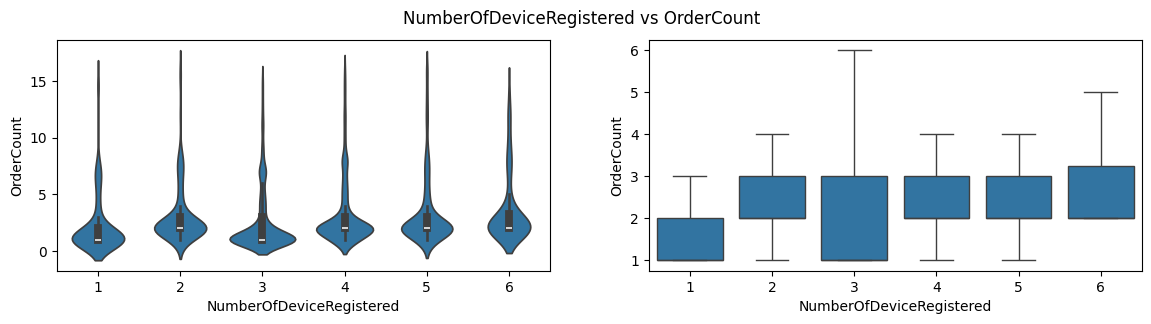

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 3))
fig.suptitle('NumberOfDeviceRegistered vs OrderCount')
axes = axes.flatten()
sns.violinplot(x='NumberOfDeviceRegistered', y='OrderCount', data=df_eda, ax=axes[0])
sns.boxplot(x='NumberOfDeviceRegistered', y='OrderCount', data=df_eda, ax=axes[1], showfliers=False)
plt.show()

### What is the most common payment method for high-value customers?
The most common patment method for high-value customers (High cashback) is Debit card then credit card

In [30]:
df_eda.groupby(['PreferredPaymentMode'])['CashbackAmount'].count()

PreferredPaymentMode
Cash on Delivery     514
Credit Card         1774
Debit Card          2314
E wallet             614
UPI                  414
Name: CashbackAmount, dtype: int64

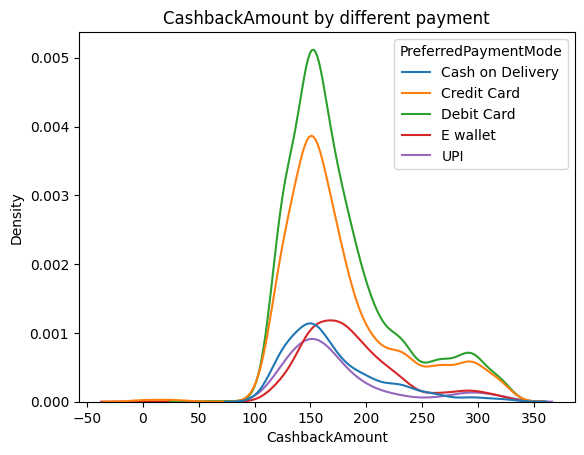

In [31]:
sns.kdeplot(x='CashbackAmount', data=df_eda, hue='PreferredPaymentMode')
plt.title('CashbackAmount by different payment')
plt.show()

### What kind of product do male or female buy the most?
The prefered order category of female and male are both mobile phone and laptop & accessory

In [33]:
df_eda_gender_cat = df_eda.groupby(['Gender', 'PreferedOrderCat'])['Churn'].count().reset_index(name='Count')
df_eda_gender_cat.sort_values('Count', ascending=False)

,Gender,PreferedOrderCat,Count
8,Male,Mobile Phone,1316
7,Male,Laptop & Accessory,1206
2,Female,Laptop & Accessory,844
3,Female,Mobile Phone,764
5,Male,Fashion,472
0,Female,Fashion,354
6,Male,Grocery,212
1,Female,Grocery,198
9,Male,Others,178
4,Female,Others,86


### What kind of product do people from different marital status buy the most?
The prefered order category of different marital status group are both mobile phone and laptop & accessory.

In [36]:
df_eda_marital_cat = df_eda.groupby(['MaritalStatus', 'PreferedOrderCat'])['Churn'].count().reset_index(name='Count')
df_eda_marital_cat

,MaritalStatus,PreferedOrderCat,Count
0,Divorced,Fashion,126
1,Divorced,Grocery,82
2,Divorced,Laptop & Accessory,296
3,Divorced,Mobile Phone,296
4,Divorced,Others,48
5,Married,Fashion,466
6,Married,Grocery,224
7,Married,Laptop & Accessory,1134
8,Married,Mobile Phone,1006
9,Married,Others,156


<div style="background-color: #f5f5dc; 
            padding: 20px 30px; 
            border-radius: 20px; 
            box-shadow: 8px 8px 15px rgba(0,0,0,0.4); 
            border: 1px solid #dcdcdc;
            color: #2c2c2c;
            font-family: sans-serif;">

<h4 style="margin-top: 0; margin-bottom: 15px; font-weight: 400; font-size: 1.1em;"><b>Other Business questions</b></h4>

<ul style="margin-bottom: 0; line-height: 1.8;">
  <li><b>Which gender has more orders:</b> Female is slightly higher than male.</li>
  <li><b>Which CityTier has higher Tenure and OrderCount?:</b> Tier 2 city has sligtly higher average tenure. Tier 3 city has slightly higher average order.</li>
  <li><b>Which CityTier has the most HourSpendOnApp?:</b>Tier 1 city has the highest HourSpendOnApp in total.</li>
  <li><b>What is the distance between warehouse to customer house in different city tiers?:</b> The distance distribution profile is similar for each city tier. Majority of distance between warehouse and home is around 25.</li>
  <li><b>Which MaritalStatus makes more OrderCount?:</b> Distribution: Married > Single > Divorced. Married people have higher bar distribution of OrderCount, indicating higher order demand.</li>
  <li><b>Does getting more cashback lead to more orders?:</b> More cashbackAmount does not lead to more orders.</li>
  <li><b>Do people spend more money when they use coupons?:</b> Do not see more spending when coupons are used.</li>
  <li><b>Do customers with high SatisfactionScore spend more hours on the app?:</b> People spend similar average amount of time on app across all satisfaction scores.</li>
  <li><b>Do customers with high SatisfactionScore have more OrderCount?:</b> People have the similar order count across different satisfaction score.</li>
  <li><b>Do customers with more HourSpendOnApp have more OrderCount?:</b> Majority of data points are located at 2, 3, and 4 hours. Comparing 2, 3, and 4 hours, the main distribution ranking: 4 hours > 3 hours > 2 hours.</li>
  <li><b>Do people with more registered devices buy more often?:</b> Increasing number of devices does not mean more order. we only see slight increase from 1 device to more than 1 device. </li>
  <li><b>What is the most common payment method for high-value customers?:</b> The most common patment method for high-value customers (High cashback) is Debit card then credit card. </li>
  <li><b>What kind of product do male or female buy the most?:</b> The prefered order category of female and male are both mobile phone and laptop & accessory. </li>
</ul>
  <li><b>What kind of product do people from different marital status buy the most?:</b> The prefered order category of different marital status group are both mobile phone and laptop & accessory. </li>
</ul>

</div>

Calcualate correlation between each numeric columns
- Complain has highest positive correlation and tenure has highest negative correlation  
Note: Correlation analysis will not indicate the combination effect of features

Tenure                        -0.349408
DaySinceLastOrder             -0.160757
CashbackAmount                -0.154118
OrderCount                    -0.028697
OrderAmountHikeFromlastYear   -0.010058
CouponUsed                    -0.008264
HourSpendOnApp                 0.018675
NumberOfAddress                0.043931
WarehouseToHome                0.076630
CityTier                       0.084703
SatisfactionScore              0.105481
NumberOfDeviceRegistered       0.107939
Complain                       0.250188
Name: Churn, dtype: float64


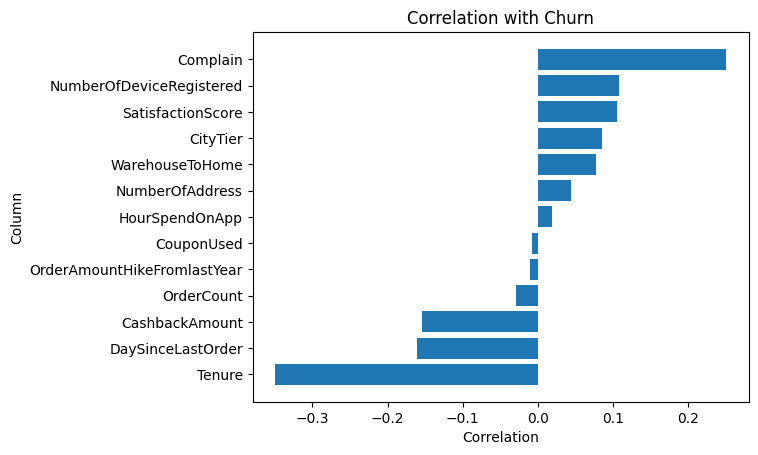

In [95]:
df_corr = df_eda.corr()
corr_with_churn = df_corr.loc['Churn'].sort_values(ascending=True).iloc[:-1]
print(corr_with_churn)
plt.barh(corr_with_churn.index, corr_with_churn.values)
plt.ylabel('Column')
plt.xlabel('Correlation')
plt.title('Correlation with Churn')
plt.show()

## Model training
### Model Choice
Considering classification prediction and dealing with missing value, I will use random forest, XGBoost, LightGBM, and CatBoost
- Random Forest (Parallel tree training/ Deeper tree (longer)
  - Process: train test split --> one hot encoding --> Model training --> Model evaluation
- XGBoost (Sequential tree training/ pruning and regularization)
  - Process: train test split --> Model training (enable_categorical=True) --> Model evaluation
- LightGBM (Leaf wise tree training/ Prone to overfitting)
  - Process: train test split --> Model training (categorical_feature=...) --> Model evaluation
- CatBoost (Symmetric tree structure/ Less prone to be overfitting)
  - Process: train test split --> Model training (cat_features=...) --> Model evaluation

### Train test split
- Use 80% for training and 20% for testing

### Preprocess & Training
- Get numeric columns and categorical columns
- One hot encoding for RF. GridSearch for RF
- GridSearch for XGBoost, lightGBM, and catboost

### Train test split

In [97]:
x = df.drop(columns=['Churn'], axis=1)
y = df['Churn']

In [98]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)
print(x_train.shape)
print(x_test.shape)
x_train.head()

(4504, 18)
(1126, 18)


,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
1787,9.0,Computer,3,16.0,Credit Card,Male,2.0,3,Fashion,1,Single,2,0,14.0,8.0,9.0,7.0,199.80
2147,6.0,Computer,3,13.0,Debit Card,Female,1.0,3,Laptop & Accessory,4,Married,1,0,17.0,0.0,1.0,2.0,143.02
1717,8.0,Mobile Phone,1,15.0,Debit Card,Male,3.0,4,Laptop & Accessory,4,Single,10,0,19.0,0.0,1.0,0.0,165.40
2292,15.0,Mobile Phone,3,11.0,Debit Card,Male,3.0,3,Fashion,4,Single,10,1,19.0,7.0,7.0,7.0,184.46
5578,12.0,Computer,1,13.0,Debit Card,Male,4.0,5,Laptop & Accessory,3,Married,4,0,12.0,3.0,8.0,8.0,178.21


### Preprocess & Training

In [99]:
num_columns = x_train.select_dtypes(include=['number']).columns.tolist()
cat_columns = x_train.select_dtypes(include=['category']).columns.tolist()
print(num_columns)
print(cat_columns)

['Tenure', 'CityTier', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']
['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender', 'PreferedOrderCat', 'MaritalStatus']


In [100]:
# Random forest training set-up
# cat_transformer = Pipeline([('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),  # OneHotEncoder makes features too sparse. So the result is worse than random guess
#                            ]
#                           )

cat_transformer = Pipeline([('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1, encoded_missing_value=-1)),
                           ]
                          )

preprocessor_rf = ColumnTransformer(
    transformers=[
        ('cat', cat_transformer, cat_columns),
    ]
)

pipline_rf = Pipeline([('preprocessor_rf', preprocessor_rf), 
                       ('rf_classifier', RandomForestClassifier(n_estimators=300, class_weight='balanced', max_depth=3, min_samples_leaf=100, random_state=42)),
                      ]
                     )

param_grid_rf = {
    # 'rf_classifier__n_estimators': [300, 500, 600, 700],  # estimators does not change a lot for variation
    # 'rf_classifier__max_depth': [3, 4, 5, 6],
    # 'rf_classifier__min_samples_leaf': [100, 150, 200]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model_rf = GridSearchCV(estimator=pipline_rf,
                        param_grid=param_grid_rf,
                        cv=cv,
                        verbose=1,
                        scoring='average_precision',
                        return_train_score=True  # Return training score to judge whjether overfitting or not
                       )


In [101]:
# XBGoost training set-up
neg = df['Churn'].value_counts()[0]
pos = df['Churn'].value_counts()[1]
scale_pos_weight= neg / pos

xgb_classifier = XGBClassifier(n_estimators=300,
                               learning_rate=0.025, 
                               scale_pos_weight=scale_pos_weight, 
                               enable_categorical=True,
                               max_depth=3,
                               subsample=0.7,  # Each tree uses only 70% of data
                               colsample_bytree=0.7,  # Each tree uses only 70% of features
                               gamma=1,
                               random_state=42
                              )

param_grid_xgb = {
    # 'n_estimators': [300, 500, 600, 700],
    # 'max_depth': [3, 4, 5, 6, 7],
    # 'min_child_weight': [1, 5, 10, 15],
    # 'subsample': [0.6, 0.7, 0.8],
    # 'colsample_bytree': [0.6, 0.7, 0.8],
    # 'gamma': [1, 1.5, 2],
    # 'child_weight': [1, 5, 10, 15, 20],
    # 'learning_rate': [0.02, 0.025, 0.05, 0.1, 0.2, 0.3]
}

model_xgb = GridSearchCV(estimator=xgb_classifier, 
                         param_grid=param_grid_xgb, 
                         cv=cv, 
                         verbose=1,
                         scoring='average_precision',
                         return_train_score=True  # Return training score to judge whjether overfitting or not
                        )


In [102]:
# LightGBM training set-up
lgbm_classifier = LGBMClassifier(n_estimators=300,
                                 learning_rate=0.025, 
                                 class_weight='balanced',
                                 num_leaves=9,
                                 subsample_freq=1,
                                 subsample=0.8,
                                 colsample_bytree=0.8
                                )


param_grid_lgbm = {
    # 'n_estimators': [300, 500, 600, 700],
    # 'num_leaves': [7, 8, 9, 10, 15, 20, 30],
    # 'subsample': [0.6, 0.7, 0.8],
    # 'colsample_bytree': [0.6, 0.7, 0.8],
    # 'learning_rate': [0.01, 0.02, 0.025, 0.05, 0.1, 0.2, 0.3]
}

model_lgbm = GridSearchCV(estimator=lgbm_classifier, 
                          param_grid=param_grid_lgbm, 
                          cv=cv, 
                          verbose=1, 
                          scoring='average_precision',
                          return_train_score=True  # Return training score to judge whjether overfitting or not
                         )

In [103]:
# Catboost training set-up
cb_classifier = CatBoostClassifier(n_estimators=300,
                                   auto_class_weights='Balanced',
                                   depth=3,
                                   random_seed=42)

param_grid_cb = {
    # 'iterations': [300, 500, 800, 900],
    # 'depth': [2, 3, 4, 5],
    # 'subsample': [0.6, 0.7, 0.8],
}

model_cb = GridSearchCV(estimator=cb_classifier, 
                        param_grid=param_grid_cb, 
                        cv=cv, 
                        verbose=1, 
                        scoring='average_precision',
                        return_train_score=True, # Return training score to judge whjether overfitting or not
                       )

In [104]:
# Model training
# model_cb.fit(x_train, y_train, cat_features=cat_columns)
# print(f'The best parameter setting: {model_cb.best_params_}')
# print(f'The average score of the best parameter setting: {model_cb.best_score_:.4f}')
# print(f'The best estimator: {model_cb.best_estimator_}')
# print(f'Evaluation score between training and validation set:{model_cb.cv_results_}')
# print('Evaluation score between training and validation set:')
# print(f'Mean_test_score: {model_cb.cv_results_["mean_test_score"]}')
# print(f'std_test_score: {model_cb.cv_results_["std_test_score"]}')
# print(f'mean_train_score: {model_cb.cv_results_["mean_train_score"]}')
# print(f'std_train_score: {model_cb.cv_results_["std_train_score"]}')

models = [model_rf, model_xgb, model_lgbm, model_cb]

for m in models:
    a = time.time()
    if m == model_cb:
        m.fit(x_train,y_train, cat_features=cat_columns)
        print(f'The best parameter setting: {m.best_params_}')
        print(f'The average score of the best parameter setting: {m.best_score_:.4f}')
        print(f'The best estimator: {m.best_estimator_}')
        # print(f'Evaluation score between training and validation set: {m.cv_results_}')
        print('Evaluation score between training and validation set:')
        print(f'Mean_test_score: {m.cv_results_["mean_test_score"]}')
        print(f'std_test_score: {m.cv_results_["std_test_score"]}')
        print(f'mean_train_score: {m.cv_results_["mean_train_score"]}')
        print(f'std_train_score: {m.cv_results_["std_train_score"]}')
        print('\n')

    else:
        m.fit(x_train,y_train)
        print(f'The best parameter setting: {m.best_params_}')
        print(f'The average score of the best parameter setting: {m.best_score_:.4f}')
        print(f'The best estimator: {m.best_estimator_}')
        print('Evaluation score between training and validation set:')
        print(f'Mean_test_score: {m.cv_results_["mean_test_score"]}')
        print(f'std_test_score: {m.cv_results_["std_test_score"]}')
        print(f'mean_train_score: {m.cv_results_["mean_train_score"]}')
        print(f'std_train_score: {m.cv_results_["std_train_score"]}')
        print('\n')

    b = time.time()
runtime = b - a
print(f'Total runtime: {runtime}s')


Fitting 5 folds for each of 1 candidates, totalling 5 fits
The best parameter setting: {}
The average score of the best parameter setting: 0.3492
The best estimator: Pipeline(steps=[('preprocessor_rf',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('ordinal',
                                                                   OrdinalEncoder(encoded_missing_value=-1,
                                                                                  handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  ['PreferredLoginDevice',
                                                   'PreferredPaymentMode',
                                                   'Gender', 'PreferedOrderCat',
                                                   'MaritalStatus'])])),
                ('rf_classifi

General Choice:
- n_estimators/ iteration: set to 300 as we do not see significant variation and bias reduction
- See overfitting: Gap of mean score between training score and validation score is high (~10%) and almost few std in training fold --> Use regulation (tree depth/ min samples in leaf/ subsample/ subsample frequency) to prevent overfitting

Outcome of grid search:
- RF
  - 'rf_classifier__max_depth': 3, 'rf_classifier__min_samples_leaf': 100: highest score (but it is still worse than random guess)
  - Reason: With class_weight='balanced', it tends to have higher FP. So the PR score is worse than random guess
- XGBoost
  - max_depth > 3 --> gap of score is higher --> Overfitting
  - subsample, colsample, gamma: lowest std and high mean score
  - learning_rate: gap of score is getting higher when learning rate is > 0.025. learning_rate=0.025 has highest score and less variation
  - learning_rate=0.025, colsample_bytree: 0.7, gamma: 1, subsample: 0.7, max_depth=3, child_weight=10
- LightGBM:
  - num_leaves = 9: gap ~ 7% with lower test std
  - colsample_bytree, subsample: Choose lowest std and high score
  - learning_rate: gap of score is getting higher when learning rate is > 0.025. learning_rate=0.025 has highest score and less variation
  - learning_rate=0.025, num_leaves = 9, colsample_bytree=0.8, subsample=0.8, subsample_freq=1
- Catboost:
  - depth=3: Gap of score is ~4% and less variation

## Model evaluation

In [135]:
# Helper function
def plot_conf_matrix(matrix):
    plt.figure(figsize=(4, 4))
    sns.heatmap(matrix, 
                cmap='Blues',
                annot=True,
                fmt='d')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

def plot_PR_curve(y, proba):
    precision, recall, thresholds = precision_recall_curve(y, proba)
    pr_score = average_precision_score(y, proba)
    
    plt.figure(figsize=(6, 4))
    plt.plot(recall, precision, label=f'PR curve (PR score: {pr_score:.3f})')
    plt.plot([0, 1], [1, 0], label='Random Guess (PR score: 0.5)')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.legend()
    plt.show()

Result of RandomForest:
              precision    recall  f1-score   support

           0       0.91      0.58      0.71       936
           1       0.26      0.73      0.38       190

    accuracy                           0.60      1126
   macro avg       0.59      0.65      0.54      1126
weighted avg       0.80      0.60      0.65      1126



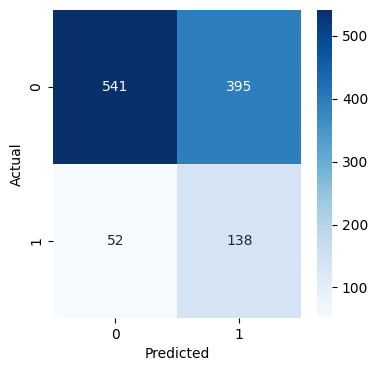

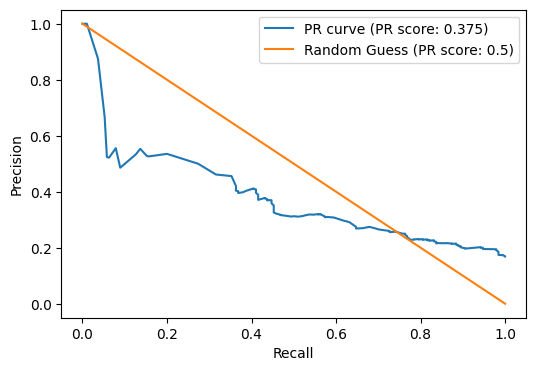

Result of XGBoost:
              precision    recall  f1-score   support

           0       0.97      0.88      0.93       936
           1       0.60      0.88      0.72       190

    accuracy                           0.88      1126
   macro avg       0.79      0.88      0.82      1126
weighted avg       0.91      0.88      0.89      1126



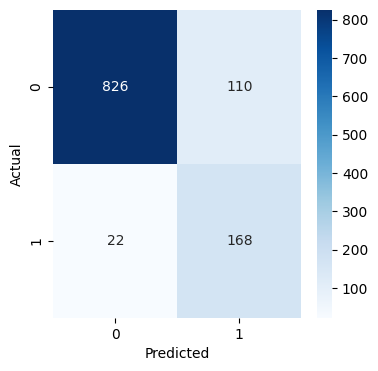

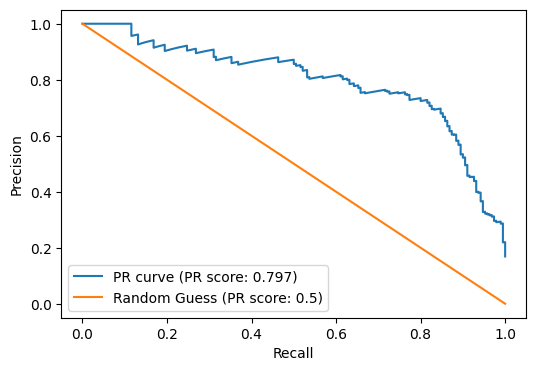

Result of LightGBM:
              precision    recall  f1-score   support

           0       0.98      0.90      0.94       936
           1       0.64      0.91      0.75       190

    accuracy                           0.90      1126
   macro avg       0.81      0.90      0.84      1126
weighted avg       0.92      0.90      0.91      1126



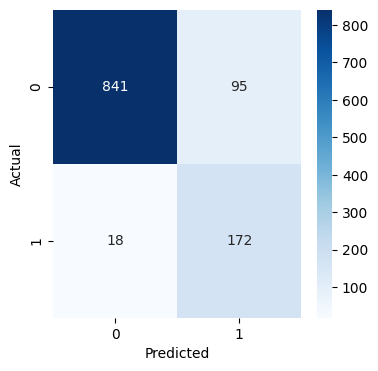

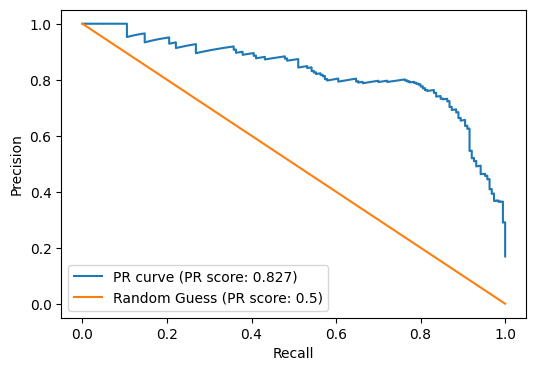

Result of CatBoost:
              precision    recall  f1-score   support

           0       0.97      0.88      0.93       936
           1       0.61      0.87      0.72       190

    accuracy                           0.88      1126
   macro avg       0.79      0.88      0.82      1126
weighted avg       0.91      0.88      0.89      1126



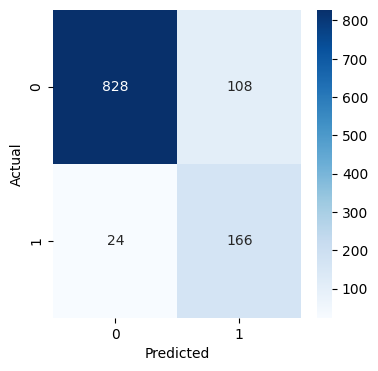

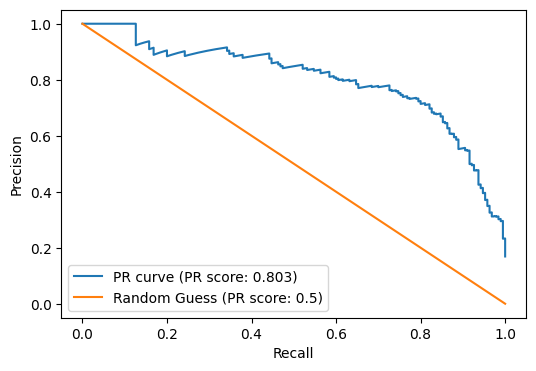

In [140]:
names = ['RandomForest', 'XGBoost', 'LightGBM', 'CatBoost']
for n, m in zip(names, models):
    y_pred_proba = m.predict_proba(x_test)[:, 1]
    y_pred = m.predict(x_test)
    report = classification_report(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)
    print(f'Result of {n}:')
    print(report)
    plot_conf_matrix(conf_matrix)
    plot_PR_curve(y_test, y_pred_proba)
    print('=' * 80)

<div style="background-color: #f5f5dc; 
            padding: 20px 30px; 
            border-radius: 20px; 
            box-shadow: 8px 8px 15px rgba(0,0,0,0.4); 
            border: 1px solid #dcdcdc;
            color: #2c2c2c;
            font-family: sans-serif;">

<h4 style="margin-top: 0; margin-bottom: 15px; font-weight: 400; font-size: 1.1em;"><b>Conclusion - Evaluation</b></h4>

<ul style="margin-bottom: 0; line-height: 1.8;">
  <li><b>Random Forest:</b> Failed with an F1 score of 0.38. This is statistically useless and underperforms a random guess.</li>
  <li><b>Model Comparison:</b> LightGBM outperformed XGBoost and CatBoost. It achieved the peak F1 score of 0.75 and PR score of 0.827.</li>
</ul>

</div>

## Action recommendation
- Compared long term customer, new customer should be the point of focus for churn possibility.
- Create a service team to tackle customer who raise complain or hot line to receive complain feedback.
- Consider to set up warehouse center or intermediate service store to increase convenience toward customer living relatively far.
- Considering higher percentage of male customer and churn possibility, should increase more products that grab their interest such as attached accessory of phone or laptop or accessory.
- Increase products or combo deal that are more attractive to single or marrried group. Such as phone, laptop, or accessory.
- Main selling point are phone, laptop, and accessory. Consider to offer related products when people purchase them.
- To predict churn, LightGBM performs the best with the PR score of 0.827. 